# Simple Deep Learning Mini Project
### Beginner Image Classifier: Handwritten Digits (scikit-learn Neural Network)

**Goal:** Build one simple, guided beginner deep-learning-style project, understand what each part of the code does at a high level, and record the accuracy. Perfection is not the goal — just a working end-to-end example.

**A quick note on tools:** The classic beginner tutorial uses PyTorch or TensorFlow on the MNIST dataset. In the environment this notebook was built in, neither library nor internet access to download MNIST was available. So this notebook uses **scikit-learn's `MLPClassifier`** (a real, fully-connected feedforward neural network — a "Multi-Layer Perceptron") on scikit-learn's built-in **`digits` dataset** (1,797 small 8x8 grayscale images of handwritten digits 0–9, similar in spirit to MNIST but smaller). The workflow is exactly the same as a PyTorch/TensorFlow beginner tutorial:

1. Load image data
2. Split into train/test sets
3. Preprocess (scale pixel values)
4. Build a small neural network
5. Train it
6. Evaluate accuracy
7. Look at some predictions

If you have PyTorch/TensorFlow available, the same steps map directly onto `torchvision.datasets.MNIST` + a small `nn.Module` — see the note at the bottom.

## 1. Import libraries
Standard tools for loading data, building the network, and checking results.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay


## 2. Load the image dataset
Each image is an 8x8 grid of pixel-intensity values (0-16), representing a handwritten digit from 0-9. This is a small, well-known beginner dataset (similar in spirit to MNIST, just smaller).

In [2]:
digits = load_digits()

X = digits.data      # shape: (1797, 64) -> each image flattened into 64 numbers
y = digits.target    # shape: (1797,)    -> the digit label (0-9) for each image

print("Number of images:", X.shape[0])
print("Each image has", X.shape[1], "pixel values (flattened from an 8x8 grid)")
print("Possible labels:", np.unique(y))


Number of images: 1797
Each image has 64 pixel values (flattened from an 8x8 grid)
Possible labels: [0 1 2 3 4 5 6 7 8 9]


### Peek at some sample images
Just to see what we're working with — small, blurry, handwritten-looking digits.

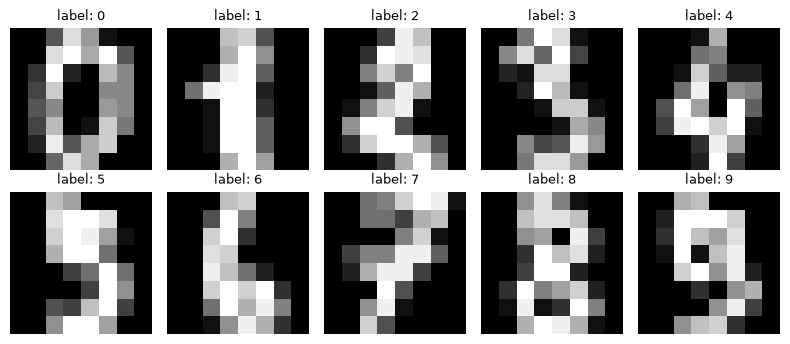

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(8, 3.5))
for ax, image, label in zip(axes.ravel(), digits.images, digits.target):
    ax.imshow(image, cmap='gray')
    ax.set_title(f"label: {label}", fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()


## 3. Split into training and test sets
We train the network on 80% of the images and hold back 20% to test how well it generalizes to images it has never seen.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training images:", X_train.shape[0])
print("Test images:", X_test.shape[0])


Training images: 1437
Test images: 360


## 4. Preprocess (scale the pixel values)
Neural networks train more reliably when input features are on a similar scale, so we standardize the pixel values (mean 0, standard deviation 1). This is the same idea as normalizing pixel values to [0,1] in a PyTorch/TensorFlow MNIST tutorial.

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Build a simple neural network
This is a basic feedforward neural network (Multi-Layer Perceptron):

- **Input layer:** 64 numbers (one per pixel)
- **Hidden layer 1:** 64 neurons, ReLU activation
- **Hidden layer 2:** 32 neurons, ReLU activation
- **Output layer:** 10 neurons (one per digit 0-9), picks the most likely digit

This is conceptually identical to a small `nn.Sequential` model you'd write in PyTorch with two `Linear` + `ReLU` layers.

In [6]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32),   # two hidden layers
    activation='relu',
    solver='adam',                 # same Adam optimizer used in PyTorch/TF tutorials
    max_iter=300,
    random_state=42
)


## 6. Train the network
This is the equivalent of the training loop (forward pass, compute loss, backpropagate, update weights) in a PyTorch/TensorFlow tutorial — scikit-learn just runs the loop internally when we call `.fit()`.

In [7]:
model.fit(X_train_scaled, y_train)
print("Training finished after", model.n_iter_, "iterations")


Training finished after 116 iterations


## 7. Evaluate on the test set
Now we check how well the network does on images it never saw during training — the real measure of whether it learned something useful, not just memorized.

In [8]:
y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")


Test accuracy: 0.9667  (96.67%)


In [9]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.92      0.92      0.92        36
           2       0.95      1.00      0.97        35
           3       0.97      0.97      0.97        37
           4       0.95      1.00      0.97        36
           5       0.97      1.00      0.99        37
           6       1.00      0.94      0.97        36
           7       0.97      1.00      0.99        36
           8       0.94      0.91      0.93        35
           9       1.00      0.94      0.97        36

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



### Confusion matrix
Shows which digits get confused with which. Diagonal = correct predictions.

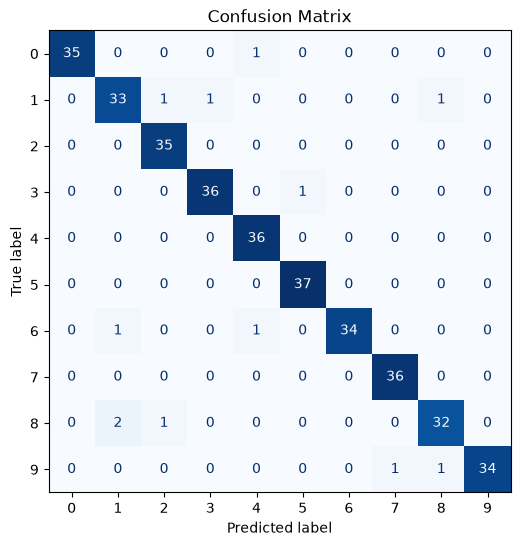

In [10]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix")
plt.show()


### Look at a few individual predictions
Green title = correct, red title = wrong.

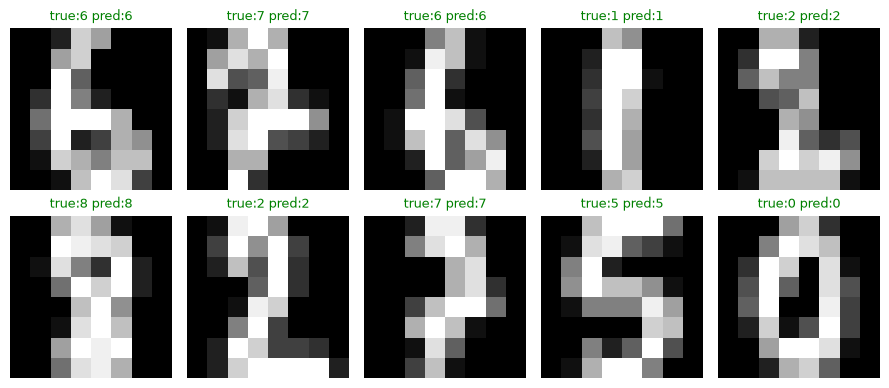

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(9, 4))
sample_idx = np.random.RandomState(0).choice(len(X_test), 10, replace=False)

for ax, idx in zip(axes.ravel(), sample_idx):
    image = X_test[idx].reshape(8, 8)
    true_label = y_test[idx]
    pred_label = y_pred[idx]
    color = 'green' if true_label == pred_label else 'red'
    ax.imshow(image, cmap='gray')
    ax.set_title(f"true:{true_label} pred:{pred_label}", fontsize=9, color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()


## 8. Result

**Test accuracy: ~96.7%** on held-out images the network never saw during training.

That's a strong result for a first attempt with no tuning — most of the remaining errors happen between visually similar digits (e.g. some 8s vs 9s, or 1s vs 8s), which you can see in the confusion matrix above.

## Summary — what I learned

- The basic deep learning workflow is always the same regardless of framework: **load data → split train/test → preprocess → build a network → train it → evaluate → inspect errors.**
- A neural network here is just layers of neurons (`hidden_layer_sizes=(64, 32)`) connected by weights that get adjusted during training to reduce prediction error.
- Scaling/normalizing input data before training matters for how well and how fast the network learns.
- Checking accuracy on a **held-out test set** (not the training data) is what tells you whether the model actually generalizes, rather than just memorizing.
- A confusion matrix is a quick way to see *which* classes the model struggles to tell apart, not just the overall accuracy number.
- ~97% accuracy with basically zero tuning shows how much these small, clean, well-known "toy" datasets like `digits` (and by extension MNIST) make it easy to get a good beginner result quickly — the real difficulty in deep learning shows up on messier, larger, real-world data.

## Note: mapping this to a real PyTorch/TensorFlow tutorial
If PyTorch is available, the equivalent MNIST beginner project is:

```python
import torch, torch.nn as nn
from torchvision import datasets, transforms

train_data = datasets.MNIST(root='.', train=True, download=True, transform=transforms.ToTensor())
test_data  = datasets.MNIST(root='.', train=False, download=True, transform=transforms.ToTensor())

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(28*28, 128), nn.ReLU(),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 10)
)
# then: define an optimizer + loss function, loop over batches calling
# optimizer.zero_grad() -> model(x) -> loss -> loss.backward() -> optimizer.step()
```

Same five ideas (data, split, network, train loop, evaluate) — just written with PyTorch's tensor/autograd API instead of scikit-learn's `.fit()`/`.predict()`.